In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = 'sales_data_practical.csv'
df = pd.read_csv(file_path)

In [3]:
print(df.head())

         Date     Product    Sales  Quantity Region
0  2024-01-05      Laptop  75000.0         3  North
1  2024-01-12       Mouse   2500.0        10  South
2  2024-02-03    Keyboard   4500.0         8   East
3  2024-02-18      Laptop  68000.0         2   West
4  2024-03-07  Headphones   6000.0         6  South


In [4]:
print(df.isnull().sum())

Date        0
Product     1
Sales       1
Quantity    0
Region      1
dtype: int64


In [7]:
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())

In [8]:
df.dropna(subset=['Product', 'Quantity', 'Region'], inplace=True)

In [9]:
print(df.isnull().sum())

Date        0
Product     0
Sales       0
Quantity    0
Region      0
dtype: int64


In [10]:
print(df.describe())

              Sales   Quantity
count     18.000000  18.000000
mean   21722.222222   7.277778
std    25069.727598   3.250440
min     2500.000000   2.000000
25%     4850.000000   5.000000
50%     8350.000000   7.500000
75%    29125.000000   9.750000
max    75000.000000  13.000000


In [11]:
product_summary = df.groupby('Product').agg({
    'Sales': 'sum',
    'Quantity': 'sum'
}).reset_index()

print(product_summary)

      Product     Sales  Quantity
0  Headphones   31700.0        27
1    Keyboard   19500.0        36
2      Laptop  215000.0         8
3     Monitor   88500.0        14
4       Mouse   36300.0        46


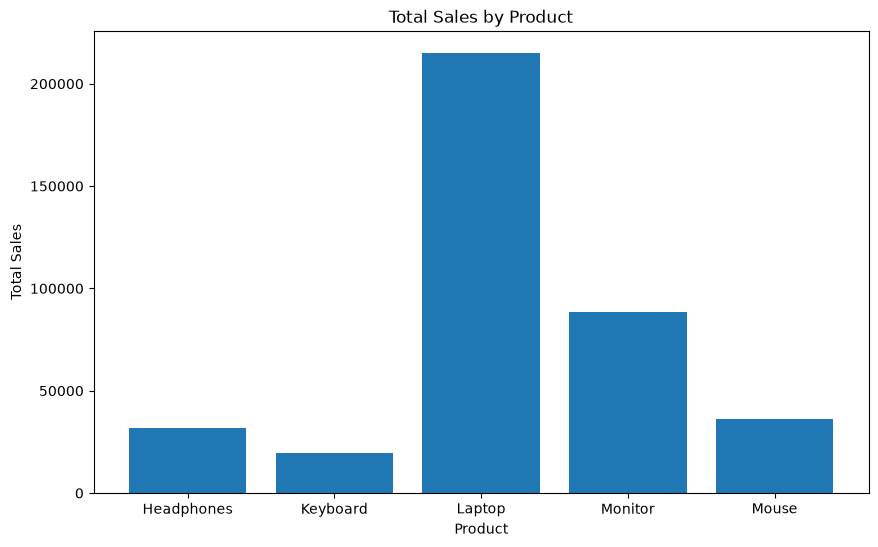

In [12]:
plt.figure(figsize=(10, 6))

plt.bar(product_summary['Product'],
        product_summary['Sales'])

plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.title('Total Sales by Product')

plt.show()

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
sales_over_time = df.groupby('Date').agg({
    'Sales': 'sum'
}).reset_index()

print(sales_over_time)

         Date    Sales
0  2024-01-05  75000.0
1  2024-01-12   2500.0
2  2024-02-03   4500.0
3  2024-02-18  68000.0
4  2024-03-07   6000.0
5  2024-03-21  27400.0
6  2024-04-04   5000.0
7  2024-04-19  72000.0
8  2024-05-06  28000.0
9  2024-05-22   8500.0
10 2024-06-08   2900.0
11 2024-07-10   5200.0
12 2024-07-27  31000.0
13 2024-08-09   9000.0
14 2024-08-24   3500.0
15 2024-09-28   4800.0
16 2024-10-13  29500.0
17 2024-10-30   8200.0


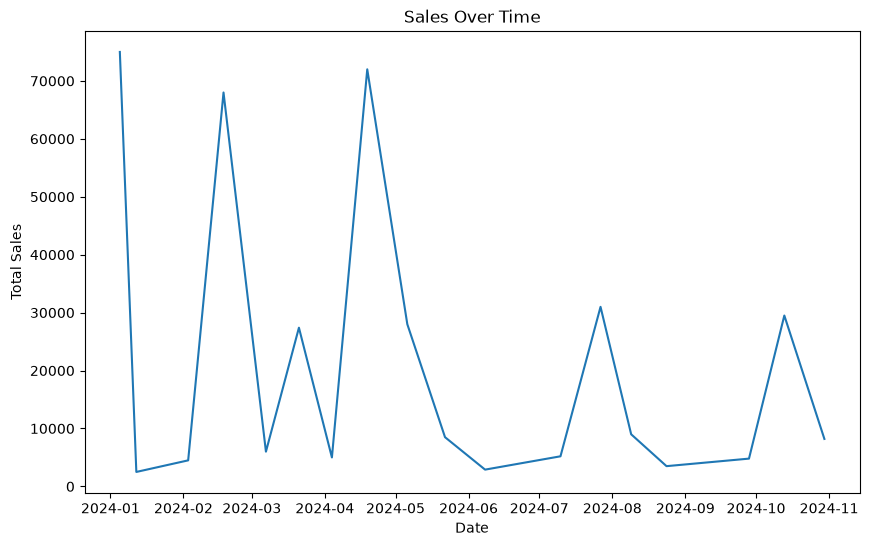

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(sales_over_time['Date'],
         sales_over_time['Sales'])

plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Sales Over Time')

plt.show()

In [16]:
pivot_table = df.pivot_table(
    values='Sales',
    index='Region',
    columns='Product',
    aggfunc='sum',
    fill_value=0
)

print(pivot_table)

Product  Headphones  Keyboard   Laptop  Monitor    Mouse
Region                                                  
East         8500.0   14300.0      0.0  31000.0      0.0
North           0.0       0.0  75000.0  29500.0  30900.0
South       23200.0       0.0  72000.0      0.0   5400.0
West            0.0    5200.0  68000.0  28000.0      0.0


In [17]:
correlation_matrix = df[['Sales', 'Quantity']].corr()

print(correlation_matrix)

             Sales  Quantity
Sales     1.000000 -0.743535
Quantity -0.743535  1.000000


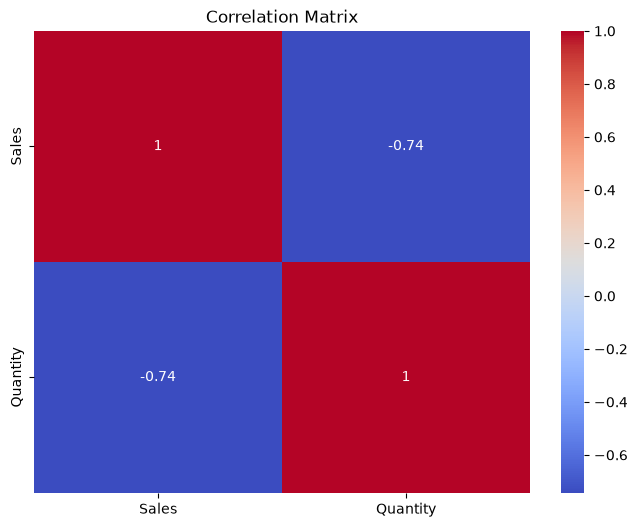

In [18]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()